In [1406]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

In [1407]:
# Plot
plot_directory = 'result/plot_set'

In [1408]:
colors = [
	'#FF0000',
	'#00FFFF',
	'#0000FF',
	'#00008B',
	'#ADD8E6',
	'#800080',
	'#7FFFD4',
	'#008000',
	'#FF00FF',
	'#FFC0CB',
	'#C0C0C0',
	'#FFA500',
	'#000000',
	'#800000',
]

In [1409]:
def load_json_file(file_path):
	try:
		with open(file_path, 'r') as file:
			data = json.load(file)
		return data
	
	except Exception as e:
		print(f"An error occurred while loading the JSON file: {e}")
		return None

In [1410]:
def extract_fpss(metric_list):
	return list(metric_list[list(metric_list.keys())[0]][0]['metric'].keys())

In [1411]:
def to_accuracy_vector(accuracy_result_seq, fpss, type='F1'):
	accuracy_vector = []
	for fps in fpss:
		accuracy_vector.append(accuracy_result_seq[fps][type])
	
	return accuracy_vector

In [1412]:
def plot_scatter(xs, ys, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	plt.scatter(xs, ys, c=colors[0], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [1413]:
def plot_scatter_label(xs, ys, labels, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	for i in range(len(xs)):
		plt.scatter(xs[i], ys[i], c=colors[labels[i]], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [1414]:
def filter_list_index(input_list, indices_to_remove):
	return [item for i, item in enumerate(input_list) if i not in indices_to_remove]

In [1415]:
def round_float_to_sigfigs(number, sigfigs):
	return round(number, sigfigs)

## Plot

In [1416]:
omv_features = ["Left-Top", "Right-Top", "Left-Bottom", "Right-Bottom", "Object-Amount", "Confidence", "IOU"]

In [1417]:
plot_filenames = sorted(os.listdir(plot_directory))
plot_video_names = sorted(list(set([f.split('_')[0] for f in plot_filenames])))

In [1418]:
fpss = extract_fpss(load_json_file(os.path.join(plot_directory, plot_video_names[0] + "_Accuracy_Result.json")))

In [1419]:
omv_videos = []
acc_videos = []

for v in plot_video_names:
	omv_dict = {}
	for fps in fpss:
		omv_dict[fps] = []
	acc_list = []

	accuracy_result = load_json_file(os.path.join(plot_directory, v + "_Accuracy_Result.json"))
	movement_result = load_json_file(os.path.join(plot_directory, v + "_Movement_Result.json"))

	for class_idx in list(accuracy_result.keys()):
		for i in range(len(accuracy_result[class_idx])):
			accuracy_vector = to_accuracy_vector(accuracy_result[class_idx][i]['metric'], fpss)
			acc_list.append(accuracy_vector)

			for fps in fpss:
				movement_vector = movement_result[class_idx][i]['movement'][fps]
				omv_dict[fps].append(movement_vector)
	
	omv_videos.append(omv_dict)
	acc_videos.append(acc_list)

In [1420]:
# Corr

# for i in range(len(plot_video_names)):
# 	video_name = plot_video_names[i]
# 	for k in range(len(fpss)):
# 		for j in range(len(omv_videos[0][fpss[0]][0])):	
# 			fps = fpss[k]

# 			omv_fps = list(np.array(omv_videos[i][fps])[:, j])
# 			acc_fps = list(np.array(acc_videos[i])[:, k])

# 			# Remove Outliers
# 			outlier_index = [l for l in range(len(omv_fps)) if omv_fps[l] == -1]
# 			omv_fps_clean = filter_list_index(omv_fps, outlier_index)
# 			acc_fps_clean = filter_list_index(acc_fps, outlier_index)

# 			title = f'{video_name}; OMV Feature {j} ({omv_features[j]}); FPS: {fps}'

# 			correlation_matrix = np.corrcoef(omv_fps_clean, acc_fps_clean)
# 			correlation_coefficient = correlation_matrix[0, 1]
# 			print(f"{title} -> Corr: {round_float_to_sigfigs(correlation_coefficient, 3)}")
# 			# plot_scatter(omv_fps_clean, acc_fps_clean, 'OMV Feature', 'ACC', title)

# 		print("")

# New Code

In [1421]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures

In [1422]:
def transpose_array(arr):
		# Transpose the input array using zip and map it back to a list
		return [list(row) for row in zip(*arr)]

In [1423]:
def my_train_test_split(x, y, test_size):
	split_point = int(len(x) * (1-test_size))
	return x[0:split_point], x[split_point:len(x)], y[0:split_point], y[split_point:len(x)]

In [1424]:
def root_mean_squared_error(y_train, y_train_pred):
	return np.sqrt(mean_squared_error(y_train, y_train_pred))

In [1425]:
OMV_FEATURE_INDEX = [5, 6]
CONDITION_INDEX = [7]
TEST_SIZE = 0.2

In [1426]:
# Dataset Build

dataset = {}

for i in range(len(plot_video_names)):
	video_name = plot_video_names[i]
	dataset[video_name] = {}
	
	for k in range(len(fpss)):
		fps = fpss[k]
		dataset[video_name][fps] = {}
		y_all = None
		x_all_t = []

		for j in range(len(omv_videos[0][fpss[0]][0])):
			omv_fps = list(np.array(omv_videos[i][fps])[:, j])
			acc_fps = list(np.array(acc_videos[i])[:, k])

			# Remove Outliers
			outlier_index = [l for l in range(len(omv_fps)) if omv_fps[l] == -1]
			omv_fps_clean = filter_list_index(omv_fps, outlier_index)
			acc_fps_clean = filter_list_index(acc_fps, outlier_index)

			if j == 0:
				y_all = acc_fps_clean.copy()
			if j in OMV_FEATURE_INDEX:
				x_all_t.append(omv_fps_clean.copy())
		
		x_all = transpose_array(x_all_t)
		dataset[video_name][fps]['y_all'] = y_all
		dataset[video_name][fps]['x_all'] = x_all
			

In [1427]:
# Condition Dataset Build

condition_dataset = {}

for i in range(len(plot_video_names)):
	video_name = plot_video_names[i]
	condition_dataset[video_name] = {}
	
	for k in range(len(fpss)):
		fps = fpss[k]
		condition_dataset[video_name][fps] = {}
		y_all = None
		x_all_t = []

		for j in range(len(omv_videos[0][fpss[0]][0])):

			omv_fps = list(np.array(omv_videos[i][fps])[:, j])
			acc_fps = list(np.array(acc_videos[i])[:, k])

			# Remove Outliers
			outlier_index = [l for l in range(len(omv_fps)) if omv_fps[l] == -1]
			omv_fps_clean = filter_list_index(omv_fps, outlier_index)
			acc_fps_clean = filter_list_index(acc_fps, outlier_index)

			if j == 0:
				y_all = acc_fps_clean.copy()
			if j in CONDITION_INDEX:
				x_all_t.append(omv_fps_clean.copy())
		
		x_all = transpose_array(x_all_t)
		condition_dataset[video_name][fps]['y_all'] = y_all
		condition_dataset[video_name][fps]['x_all'] = x_all
			

In [1428]:
def lr_inference(x_train, x_test, y_train, y_test):
	lr_model = LinearRegression()
	lr_model.fit(x_train, y_train)

	y_train_pred = lr_model.predict(x_train)
	y_test_pred = lr_model.predict(x_test)

	train_mse = root_mean_squared_error(y_train, y_train_pred)
	test_mse = root_mean_squared_error(y_test, y_test_pred)
	
	# print(f"Linear Regression Train MSE: {round(train_mse, 4)}")
	# print(f"Linear Regression Test MSE: {round(test_mse, 4)}")

	return train_mse, test_mse

In [1429]:
def find_all_indices(lst, element):
		"""
		Returns a list of all indices of 'element' in the given list 'lst'.
		
		Parameters:
		lst (list): The list to search in.
		element: The element to find indices for.
		
		Returns:
		list: A list of indices where 'element' is found in 'lst'.
		"""
		return [index for index, value in enumerate(lst) if value == element]

In [1430]:
def extract_elements_by_indices(lst, indices):
		"""
		Extracts elements from 'lst' according to the specified 'indices'.
		
		Parameters:
		lst (list): The list to extract elements from.
		indices (list): A list of indices specifying which elements to extract.
		
		Returns:
		list: A list of elements from 'lst' at the specified indices.
		"""
		return [lst[i] for i in indices if i < len(lst)]

In [1431]:
# # One accuracy for each video (multiple classifier)
# for k in range(len(fpss)):
# 	fps = fpss[k]

# 	# print(f"FPS: {fps}")

# 	for i in range(len(plot_video_names)):
# 		video_name = plot_video_names[i]	

# 		x_all = dataset[video_name][fps]['x_all']
# 		y_all = dataset[video_name][fps]['y_all']

# 		x_train, x_test, y_train, y_test = my_train_test_split(x_all, y_all, TEST_SIZE)

# 		x_all_condition = condition_dataset[video_name][fps]['x_all']
# 		y_all_condition = condition_dataset[video_name][fps]['y_all']

# 		x_train_condition, x_test_condition, _, _ = my_train_test_split(x_all_condition, y_all_condition, TEST_SIZE)
# 		x_train_condition = [int(s[0]) for s in x_train_condition]
# 		x_test_condition = [int(s[0]) for s in x_test_condition]

# 		# LR
# 		lr_model = LinearRegression()
# 		lr_model.fit(x_train, y_train)

# 		y_train_pred = lr_model.predict(x_train)
# 		y_test_pred = lr_model.predict(x_test)

# 		x_train_condition_set = set(sorted(x_train_condition))
		
# 		train_condition_set_list = list(x_train_condition_set)
# 		train_condition_rmse_list = []
# 		for amount in train_condition_set_list:
# 			amount_index = find_all_indices(x_train_condition, amount)
# 			y_train_pred_amount = extract_elements_by_indices(y_train_pred, amount_index)
# 			y_train_amount = extract_elements_by_indices(y_train, amount_index)
# 			train_rmse_amount = root_mean_squared_error(y_train_amount, y_train_pred_amount)

# 			train_condition_rmse_list.append(train_rmse_amount)

In [1432]:
def distance_list(list1, list2):
		"""
		Calculates the square distance between corresponding elements in two lists.
		
		Parameters:
		list1 (list): The first list of numeric values.
		list2 (list): The second list of numeric values, must be the same length as list1.
		
		Returns:
		list: A list of square distances for each pair of corresponding elements.
		"""
		if len(list1) != len(list2):
				raise ValueError("Both lists must be of the same length.")
		
		return [abs(a - b) for a, b in zip(list1, list2)]

In [1433]:
def normalize_list(data):
		"""
		Normalizes a list of numbers to be within the range [0, 1].
		
		Parameters:
		data (list): A list of numeric values.
		
		Returns:
		list: A list of normalized values within the range [0, 1].
		"""
		min_val = min(data)
		max_val = max(data)
		
		# Avoid division by zero if all values are the same
		if min_val == max_val:
				return [0 for _ in data]
		
		return [(value - min_val) / (max_val - min_val) for value in data]

In [1434]:
from sklearn.cluster import KMeans

def cluster_floats(float_list, num_clusters):
		"""
		Clusters a list of floats into a specified number of clusters.
		
		Parameters:
		float_list (list): The list of float numbers to be clustered.
		num_clusters (int): The number of clusters.
		
		Returns:
		list of tuples: A list where each tuple represents a cluster range as (min, max).
		"""
		# Convert list to numpy array for clustering
		data = np.array(float_list).reshape(-1, 1)
		
		# Perform k-means clustering
		kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(data)
		labels = kmeans.labels_
		
		# Create clusters as ranges
		clusters = []
		for cluster in range(num_clusters):
				cluster_values = [float_list[i] for i in range(len(float_list)) if labels[i] == cluster]
				cluster_min = min(cluster_values)
				cluster_max = max(cluster_values)
				clusters.append((cluster_min, cluster_max))
		
		# Sort clusters by their range starting values
		clusters.sort()
		
		return clusters

In [1435]:
# Average accuracy among all videos (one classifier)

train_condition_all_rmse_all_fps = {}
test_condition_all_rmse_all_fps = {}
train_condition_all_size_all_fps = None
test_condition_all_size_all_fps = None

for k in range(0, len(fpss)-1): # Ignore FPS=30
	fps = fpss[k]

	# print(f"FPS: {fps}")

	x_train_all=[]
	x_test_all=[]
	y_train_all=[]
	y_test_all=[]
	x_train_condition_all = []
	x_test_condition_all = []
	for i in range(len(plot_video_names)):
		video_name = plot_video_names[i]	

		x_all = dataset[video_name][fps]['x_all']
		y_all = dataset[video_name][fps]['y_all']

		x_train, x_test, y_train, y_test = my_train_test_split(x_all, y_all, TEST_SIZE)

		x_all_condition = condition_dataset[video_name][fps]['x_all']
		y_all_condition = condition_dataset[video_name][fps]['y_all']

		x_train_condition, x_test_condition, _, _ = my_train_test_split(x_all_condition, y_all_condition, TEST_SIZE)
		x_train_condition = [s[0] for s in x_train_condition]
		x_test_condition = [s[0] for s in x_test_condition]

		x_train_all.extend(x_train)
		x_test_all.extend(x_test)
		y_train_all.extend(y_train)
		y_test_all.extend(y_test)
		x_train_condition_all.extend(x_train_condition)
		x_test_condition_all.extend(x_test_condition)

	# LR
	lr_model = LinearRegression()
	lr_model.fit(x_train_all, y_train_all)
	
	# Train Error
	y_train_pred_all = lr_model.predict(x_train_all)
	x_train_condition_all = normalize_list(x_train_condition_all)
	train_condition_all_set_list = [(0.01*i, 0.01*(i+1)) for i in range(10)]
	train_condition_all_rmse_list = []
	for i in range(len(train_condition_all_set_list)):
		size_range = train_condition_all_set_list[i]
		index_list = [index for index, value in enumerate(x_train_condition_all) if (value >= size_range[0] and value < size_range[1])]
		y_train_pred_all_amount = extract_elements_by_indices(y_train_pred_all, index_list)
		y_train_all_amount = extract_elements_by_indices(y_train_all, index_list)
		train_all_rmse_amount = root_mean_squared_error(y_train_all_amount, y_train_pred_all_amount)
		train_condition_all_rmse_list.append(train_all_rmse_amount)
	train_condition_all_rmse_all_fps[fps] = train_condition_all_rmse_list

train_condition_all_size_all_fps = [(0.01*i, 0.01*(i+1)) for i in range(10)]

In [1436]:
def average_across_dict(data_dict):
		"""
		Calculates the average across corresponding elements of each list in a dictionary.
		
		Parameters:
		data_dict (dict): A dictionary where each key has a list of numeric values of the same length.
		
		Returns:
		list: A list containing the averages of corresponding elements across all lists in the dictionary.
		"""
		# Transpose the lists to group corresponding elements together
		grouped_values = zip(*data_dict.values())
		
		# Calculate the average for each group
		averages = [sum(values) / len(values) for values in grouped_values]
		
		return averages

In [1437]:
def plot_mutiple_lines(xs, yss, x_label, y_label, y_legends, title, fig_size, label_size=28, font_size=32, legend_size=20):
	fig, ax1 = plt.subplots(figsize=fig_size)

	for i in range(len(yss)):
		ax1.plot(xs, yss[i], color=colors[i], label=y_legends[i])

	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y_label, fontsize=font_size)
	# ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	plt.legend(fontsize=legend_size)
	plt.grid(True)

	plt.show()

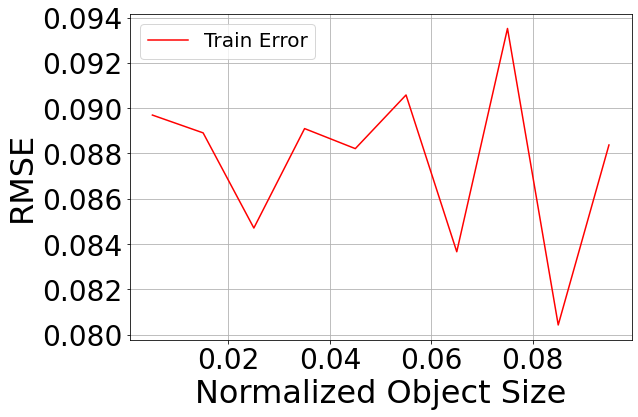

In [1438]:
train_condition_all_rmse_all_fps_avg = average_across_dict(train_condition_all_rmse_all_fps)
train_condition_all_size_middle_point = [round(0.5*(p[0]+p[1]), 3) for p in train_condition_all_size_all_fps]
plot_mutiple_lines(train_condition_all_size_middle_point, [train_condition_all_rmse_all_fps_avg], 'Normalized Object Size', 'RMSE', ['Train Error'], '', (9, 6))